# Notebook 2 — Create the Labels

**Task 2 — From Tables to Notebooks · Qafza Tech MLOps Training 2026/2027**

**Goal:** turn `order_status` + the delivery dates from `ml_table.csv` into a real `is_late` label, check it makes sense on real orders, and see whether we're dealing with class imbalance.

**What we'll do:**
1. Load the artifact from Notebook 1
2. Decide which orders can even have a label
3. Build `is_late` from the dates
4. Sanity-check the label on real orders, by hand
5. Look at the class distribution and decide if it's imbalanced
6. Save the labeled table


## 1. Load the Artifact from Notebook 1

We parse the date columns on the way in — CSV doesn't remember dtypes, so every notebook that reads a date column has to re-parse it.


In [1]:
from pathlib import Path
import pandas as pd

ARTIFACTS_DIR = Path("artifacts/tables")

DATE_COLS = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

ml_table = pd.read_csv(ARTIFACTS_DIR / "ml_table.csv", parse_dates=DATE_COLS)
print("Loaded:", ml_table.shape)
ml_table[["order_id", "order_status"] + DATE_COLS].head(3)


Loaded: (99441, 28)


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


## 2. Which Orders Can Actually Be Labeled?

The label only makes sense for orders that **actually arrived** — you can't say an order was "late" or "on time" if it was canceled or never delivered. Concretely, we need:

- `order_status == "delivered"`
- `order_delivered_customer_date` is not null (the real arrival date)
- `order_estimated_delivery_date` is not null (what we're comparing against)

Everything else gets dropped **from the labeled table** — it simply isn't a training example for this problem.


In [2]:
print("Row counts before filtering, by status:")
print(ml_table["order_status"].value_counts())
print()

is_delivered = ml_table["order_status"] == "delivered"
has_actual_date = ml_table["order_delivered_customer_date"].notna()
has_estimated_date = ml_table["order_estimated_delivery_date"].notna()

labelable = ml_table[is_delivered & has_actual_date & has_estimated_date].copy()

print(f"Total orders          : {len(ml_table):,}")
print(f"Labelable orders      : {len(labelable):,}")
print(f"Dropped (no label)    : {len(ml_table) - len(labelable):,}")


Row counts before filtering, by status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders          : 99,441
Labelable orders      : 96,470
Dropped (no label)    : 2,971


In [3]:
# A quick look at what we're dropping and why, so it's not a silent decision.
dropped = ml_table[~(is_delivered & has_actual_date & has_estimated_date)]
print("Dropped orders by status:")
print(dropped["order_status"].value_counts())

# Rare edge case worth knowing about: status says 'delivered' but a date is still missing.
edge_case = dropped[dropped["order_status"] == "delivered"]
print(f"\n'delivered' orders missing a date anyway: {len(edge_case)}")


Dropped orders by status:
order_status
shipped        1107
canceled        625
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

'delivered' orders missing a date anyway: 8


## 3. Build the Label

```
is_late = 1  if order_delivered_customer_date > order_estimated_delivery_date
is_late = 0  otherwise
```


In [4]:
labeled = labelable.copy()
labeled["is_late"] = (
    labeled["order_delivered_customer_date"] > labeled["order_estimated_delivery_date"]
).astype(int)

labeled[[
    "order_id", "order_estimated_delivery_date", "order_delivered_customer_date", "is_late",
]].head(5)


,order_id,order_estimated_delivery_date,order_delivered_customer_date,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-18,2017-10-10 21:25:13,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-13,2018-08-07 15:27:45,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-09-04,2018-08-17 18:06:29,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-15,2017-12-02 00:28:42,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-26,2018-02-16 18:17:02,0


## 4. Sanity-Check the Label by Hand

Before trusting a derived column, look at a handful of real rows and verify the logic manually — one clearly late, one clearly on time.


In [5]:
sample_late = labeled[labeled["is_late"] == 1].sample(3, random_state=42)
sample_on_time = labeled[labeled["is_late"] == 0].sample(3, random_state=42)

cols = ["order_id", "order_estimated_delivery_date", "order_delivered_customer_date", "is_late"]
print("Sampled LATE orders (delivered date should be AFTER estimated date):")
display(sample_late[cols])

print("\nSampled ON-TIME orders (delivered date should be ON OR BEFORE estimated date):")
display(sample_on_time[cols])


Sampled LATE orders (delivered date should be AFTER estimated date):


,order_id,order_estimated_delivery_date,order_delivered_customer_date,is_late
14181,5077287aeb4c2ee7662411de334235ab,2018-01-05,2018-01-07 12:53:38,1
80153,88d845f17b3dbf8c5d642a0ffcea2e48,2018-04-19,2018-04-30 22:48:43,1
33370,556a854645a80f5c86ec936469f6903a,2018-04-13,2018-04-18 20:57:27,1



Sampled ON-TIME orders (delivered date should be ON OR BEFORE estimated date):


,order_id,order_estimated_delivery_date,order_delivered_customer_date,is_late
49737,984b736f36379b94a92c737061fef6b4,2017-05-25,2017-05-10 09:51:55,0
77580,9751ad9e269564b0b79cc17a82fe06c4,2017-12-06,2017-11-23 14:58:25,0
7527,e636e64e725aeff4955e397f34162049,2018-05-25,2018-05-16 18:28:49,0


Both groups check out: the "late" sample all have a delivered date after the estimate, the "on time" sample all have a delivered date on or before it. The label logic is doing what we think it's doing.

## 5. Class Distribution — Do We Have an Imbalance Problem?


In [6]:
counts = labeled["is_late"].value_counts().sort_index()
rates = labeled["is_late"].value_counts(normalize=True).sort_index()

print("Counts:")
print(counts)
print()
print("Proportions:")
print(rates.round(4))

minority_rate = rates.min()
print(f"\nMinority class share: {minority_rate:.1%}")


Counts:
is_late
0    88644
1     7826
Name: count, dtype: int64

Proportions:
is_late
0    0.9189
1    0.0811
Name: proportion, dtype: float64

Minority class share: 8.1%


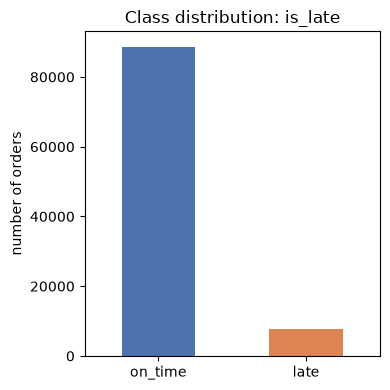

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
counts.rename({0: "on_time", 1: "late"}).plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Class distribution: is_late")
ax.set_xlabel("")
ax.set_ylabel("number of orders")
plt.xticks(rotation=0)
plt.tight_layout()

Path("artifacts/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("artifacts/figures/label_class_distribution.png", dpi=120)
plt.show()


**Verdict:** with a minority class share printed above — if it's well under ~30%, this is a real class-imbalance problem, not a minor detail. That decision matters for two things later on:

- **Notebook 3:** if we split randomly, we need to keep this same ratio in every split.
- **Notebook 6:** accuracy alone would be a misleading metric here — a model that always predicts "on time" could still score high accuracy while catching zero late deliveries. We'll need a metric (and possibly `class_weight="balanced"`) that accounts for this.

## 6. Save the Labeled Table


In [8]:
out_path = ARTIFACTS_DIR / "labeled_table.csv"
labeled.to_csv(out_path, index=False)
print("Saved:", out_path, "-", labeled.shape)


Saved: artifacts\tables\labeled_table.csv - (96470, 29)


## Recap

- `labeled_table.csv` keeps only orders where a late/on-time label is actually defined (`delivered`, with both dates present).
- New column: `is_late` (1 = late, 0 = on time), verified by hand on real orders.
- We now know whether — and how badly — the classes are imbalanced.

**A note on leakage, made explicit here so it isn't forgotten later:** `order_delivered_customer_date` and `order_status` are what the label is *made from* — they must never be used as model **features**. `order_estimated_delivery_date`, on the other hand, is shown to the customer at purchase time, so it's fair game as a feature (e.g. "how many days did we promise?"). `order_delivered_carrier_date` sits in between — it's a real event that hasn't happened yet at purchase time, so we'll treat it as **not usable** as a feature too. We'll apply this rule for real in Notebook 5.

**Next up — Notebook 3:** split into train / validation / test *before* we do any deep analysis.
